In [1]:
%pip install psycopg2 polars connectorx

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import polars as pl
from dotenv import load_dotenv, find_dotenv
import lightgbm as lgb
from sqlalchemy import create_engine
import psycopg2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

import pickle
import json
from pathlib import Path
from datetime import datetime, timezone

In [3]:
def db_connection_string():
    load_dotenv(find_dotenv())

    host = 'localhost'
    port = 5433
    db = os.getenv('POSTGRES_DB')
    user = os.getenv('POSTGRES_USER')
    password = os.getenv('POSTGRES_PASSWORD')
    
    return f'postgresql://{user}:{password}@{host}:{port}/{db}'

In [4]:
def query_database(query: str):
    conn_str = db_connection_string()
    
    df = pl.read_database_uri(query=query, uri=conn_str)

    decimal_cols = [c for c, dtype in df.schema.items() if dtype == pl.Decimal]
    df = df.with_columns([pl.col(c).cast(pl.Float64) for c in decimal_cols])
    df_pandas = df.to_pandas()

    return df_pandas

In [5]:
query = """
    SELECT fix.season, feat.*
    FROM dev_ml.training_features feat
    JOIN dev_serving.dim_fixture fix
    ON feat.fixture_key = fix.fixture_key
"""

df_features = query_database(query)
df_features

,season,player_game_key,fixture_key,player_id,fpl_position,team_id,at_home,games_prior,appearance_rate,starting_rate,...,prev_season_influence_per_90,prev_season_creativity_per_90,prev_season_threat_per_90,prev_season_ict_index_per_90,prev_season_expected_goals_per_90,prev_season_expected_assists_per_90,prev_season_expected_goal_involvements_per_90,prev_season_expected_goal_chain_per_90,prev_season_expected_goal_buildup_per_90,league_avg_bps_this_season
0,2017,2017_100_128,2017_100,97299,DEF,43,False,9,1.000000,0.888889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
1,2017,2017_100_129,2017_100,108824,DEF,35,True,9,0.333333,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
2,2017,2017_100_218,2017_100,15749,GKP,43,False,9,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
3,2017,2017_100_219,2017_100,20310,GKP,43,False,9,0.333333,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
4,2017,2017_100_220,2017_100,42593,DEF,43,False,9,0.888889,0.875000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256722,2027,2027_9_559,2027_9,632794,MID,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868
256723,2027,2027_9_567,2027_9,470551,GKP,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868
256724,2027,2027_9_579,2027_9,445087,DEF,14,False,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868
256725,2027,2027_9_593,2027_9,463726,DEF,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868


In [6]:
query = """
    SELECT 
        player_game_key,
        total_points_recalculated
    FROM
        dev_serving.fact_player_game
"""

df_target = query_database(query)
df_target

,player_game_key,total_points_recalculated
0,2022_167_457,0.0
1,2026_10_292,0.0
2,2020_128_224,0.0
3,2022_194_493,0.0
4,2024_311_96,1.0
...,...,...
256722,2024_303_117,2.0
256723,2023_172_10,1.0
256724,2026_339_613,10.0
256725,2017_4_172,0.0


In [7]:
df_all = pd.merge(df_features, df_target, on='player_game_key', how='inner')
df_all

,season,player_game_key,fixture_key,player_id,fpl_position,team_id,at_home,games_prior,appearance_rate,starting_rate,...,prev_season_creativity_per_90,prev_season_threat_per_90,prev_season_ict_index_per_90,prev_season_expected_goals_per_90,prev_season_expected_assists_per_90,prev_season_expected_goal_involvements_per_90,prev_season_expected_goal_chain_per_90,prev_season_expected_goal_buildup_per_90,league_avg_bps_this_season,total_points_recalculated
0,2017,2017_100_128,2017_100,97299,DEF,43,False,9,1.000000,0.888889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,7.0
1,2017,2017_100_129,2017_100,108824,DEF,35,True,9,0.333333,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,0.0
2,2017,2017_100_218,2017_100,15749,GKP,43,False,9,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,0.0
3,2017,2017_100_219,2017_100,20310,GKP,43,False,9,0.333333,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,0.0
4,2017,2017_100_220,2017_100,42593,DEF,43,False,9,0.888889,0.875000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256722,2027,2027_9_559,2027_9,632794,MID,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868,1.0
256723,2027,2027_9_567,2027_9,470551,GKP,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868,1.0
256724,2027,2027_9_579,2027_9,445087,DEF,14,False,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868,1.0
256725,2027,2027_9_593,2027_9,463726,DEF,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868,1.0


In [8]:
def preprocess_data(df, fit_categories=None, fit=False):
    # Drop identifier and descriptive columns
    id_cols = [col for col in df.columns if col.endswith('_id') or col.endswith('_key') or col == 'season']
    df = df.drop(columns=id_cols)

    # Convert boolean columns to integer
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()                
    for col in bool_cols:
        df[col] = df[col].astype('int')

    # Convert object columns to category type
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    categories = {} if fit else fit_categories
    
    for col in cat_cols:
        if fit:
            df[col] = df[col].astype('category')
            categories[col] = df[col].cat.categories
        else:
            df[col] = pd.Categorical(df[col], categories=categories[col])

    # Rename target variable
    if 'total_points_recalculated' in df.columns:
        df.rename(columns={'total_points_recalculated': 'points'}, inplace=True)

    return df, (categories if fit else None)

In [9]:
train = df_all[df_all['season'] < 2025].copy()
test = df_all[df_all['season'] >= 2025].copy()

In [10]:
df_training, categories = preprocess_data(train, fit=True)
df_test, _ = preprocess_data(test, fit_categories=categories, fit=False)

X_train = df_training.drop(columns=['points'])
y_train = df_training['points']

X_test = df_test.drop(columns=['points'])
y_test = df_test['points']

In [11]:
def train_baseline_model(model, X_train, y_train):    
    model.fit(X_train, y_train)
    
    yhat_train = model.predict(X_train)
    mae = mean_absolute_error(y_train, yhat_train)
    mse = mean_squared_error(y_train, yhat_train)
    spearman = spearmanr(y_train, yhat_train).correlation
    
    print(f'Training MAE: {mae}')
    print(f'Training MSE: {mse}')
    print(f'Training Spearman: {spearman}')
    
    return model, yhat_train

In [12]:
def test_baseline_model(model, X_test, y_test):
    yhat_test = model.predict(X_test)

    mae = mean_absolute_error(y_test, yhat_test)
    mse = mean_squared_error(y_test, yhat_test)
    spearman = spearmanr(y_test, yhat_test).correlation
    
    print(f'Test MAE: {mae}')
    print(f'Test MSE: {mse}')
    print(f'Test Spearman: {spearman}')

    return yhat_test

In [13]:
lgbm = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_l2, yhat_train = train_baseline_model(lgbm, X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54077
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 247
[LightGBM] [Info] Start training from score 1.325831
Training MAE: 1.04654856458235
Training MSE: 3.516575070659153
Training Spearman: 0.7097071206119133


In [14]:
yhat_test = test_baseline_model(model_l2, X_test, y_test)

Test MAE: 1.0270434865091145
Test MSE: 3.790800308291212
Test Spearman: 0.699758012505235


In [15]:
def get_summary(train_test, X, yhat):
    df = train_test.copy()
    df.loc[X.index, 'yhat'] = yhat

    query = """
        SELECT p.web_name, pg.player_game_key, pg.fixture_key, pg.player_id, pg.total_points_recalculated
        FROM dev_serving.fact_player_game pg
        JOIN dev_serving.dim_player p
        ON pg.player_id = p.player_id
    """

    df_info = query_database(query)

    df_summary = pd.merge(df_info, df[['player_game_key', 'yhat']], on='player_game_key', how='inner')

    return df_summary

In [16]:
get_summary(train, X_train, yhat_train).sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
123013,Palmer,2024_325_362,2024_325,244851,26.0,17.642260
5078,Haaland,2024_39_355,2024_39,223094,20.0,15.250365
19321,De Bruyne,2022_330_251,2022_330,61366,24.0,14.938295
156650,Sterling,2019_107_270,2019_107,103955,21.0,14.385375
88217,Kane,2017_336_403,2017_336,78830,24.0,13.971039
189805,Hazard,2019_42_122,2019_42,42786,20.0,13.842071
105630,Kane,2017_374_403,2017_374,78830,17.0,13.646479
161054,De Bruyne,2020_377_215,2020_377,61366,19.0,13.641135
184708,Haaland,2023_49_318,2023_49,223094,17.0,13.427361
95691,Agüero,2018_264_257,2018_264,37572,21.0,13.038617


In [17]:
df_testing_summary = get_summary(test, X_test, yhat_test)
df_testing_summary.sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
46270,Haaland,2025_9_351,2025_9,223094,7.0,10.857297
5069,M.Salah,2025_4_328,2025_4,118748,14.0,10.514457
40004,M.Salah,2026_1_381,2026_1,118748,8.0,10.341796
17770,Haaland,2026_7_430,2026_7,223094,13.0,10.316441
27982,Haaland,2027_8_411,2027_8,223094,2.0,9.965482
46416,Saka,2025_2_17,2025_2,223340,12.0,8.881103
53777,Haaland,2026_307_430,2026_307,223094,0.0,8.876707
41880,B.Fernandes,2027_4_426,2027_4,141746,2.0,8.018762
13861,Haaland,2025_227_351,2025_227,223094,12.0,7.990087
52820,Haaland,2025_197_351,2025_197,223094,13.0,7.901602


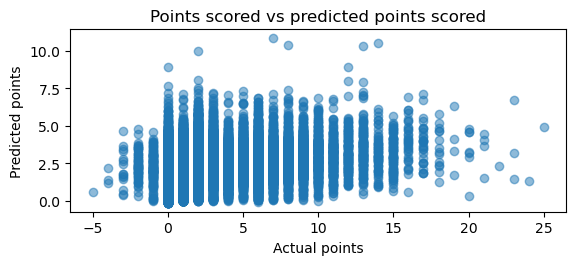

In [18]:
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.xlabel('Actual points')
plt.ylabel('Predicted points')
plt.axis('scaled')
plt.title('Points scored vs predicted points scored')
plt.show()

In [19]:
def get_aggregates(df_summary):
    df_agg = df_summary.groupby(['player_id', 'web_name']).agg(
        pred_std=('yhat', 'std'),
        actual_std=('total_points_recalculated', 'std'),
        pred_mean=('yhat', 'mean'),
        actual_mean=('total_points_recalculated', 'mean'),
        n=('yhat', 'count')
    ).query('n >= 10')

    return df_agg

In [20]:
df_agg = get_aggregates(df_testing_summary)
df_agg.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,1.492902,5.288236,5.249575,6.144737,76
223094,Haaland,1.611774,4.842520,5.641067,5.666667,81
141746,B.Fernandes,1.112908,4.944538,4.354929,5.432099,81
446008,Mbeumo,0.925637,4.392895,4.519813,5.049383,81
178186,Bowen,0.872381,3.669696,4.464170,5.000000,76
437730,Semenyo,0.694833,4.124153,4.290311,4.938272,81
222531,Gibbs-White,0.725544,4.153126,3.653960,4.567901,81
244850,Rogers,0.729923,3.754791,3.665207,4.432099,81
244851,Palmer,1.643504,5.004196,4.217940,4.395062,81


### Notes
- Among top players, predicted mean is largely in the correct order compared to actual mean. However test predictions are consistently underpredicted.
- Predicted standard deviation is ~20% of actual values, this may be expected of a noisy target variable such as fpl points.

In [21]:
def residual_plot(df_agg):
    df_agg['residual'] = df_agg['pred_mean'] - df_agg['actual_mean']
    
    print(df_agg[['actual_mean', 'residual']].corr())
    
    plt.scatter(df_agg['actual_mean'], df_agg['residual'], alpha=0.5)
    plt.xlabel('Actual mean points')
    plt.ylabel('Predicted - Actual')
    plt.title('Actual mean points vs Residual')
    plt.show()

             actual_mean  residual
actual_mean     1.000000 -0.551477
residual       -0.551477  1.000000


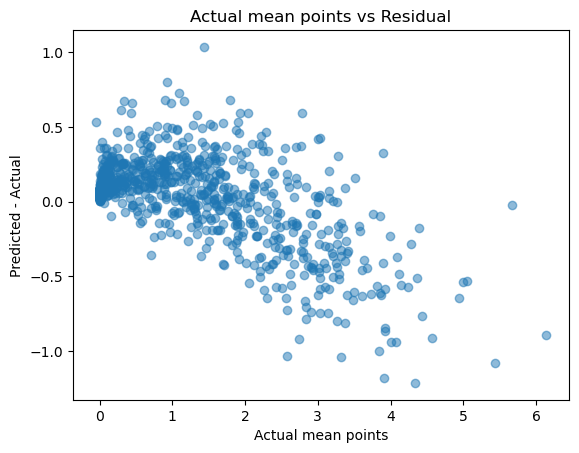

In [22]:
residual_plot(df_agg)

Strong positive correlation between how good a player is and how much the model underestimates them

In [23]:
model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_l1, yhat_train_l1 = train_baseline_model(model, X_train, y_train)

yhat_test_l1 = test_baseline_model(model_l1, X_test, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54077
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 247
Training MAE: 1.0068337172450987
Training MSE: 5.116762989741161
Training Spearman: 0.6736649786325237
Test MAE: 0.8839790742137039
Test MSE: 4.355846884656999
Test Spearman: 0.6896609875714004


In [24]:
df_testing_summary_l1 = get_summary(test, X_test, yhat_test_l1)
df_testing_summary_l1.sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
8755,Haaland,2025_37_351,2025_37,223094,13.0,5.733779
661,Haaland,2025_30_351,2025_30,223094,17.0,5.710786
18490,João Pedro,2027_33_165,2027_33,475168,12.0,5.629132
21799,Isak,2025_40_401,2025_40,219168,1.0,5.605018
35544,Haaland,2026_64_430,2026_64,223094,8.0,5.586568
57865,Haaland,2026_57_430,2026_57,223094,16.0,5.550718
36806,Bowen,2026_40_624,2026_40,178186,2.0,5.536496
25102,Bowen,2026_49_624,2026_49,178186,9.0,5.456907
3170,Haaland,2025_47_351,2025_47,223094,9.0,5.453552
52558,Haaland,2027_26_411,2027_26,223094,9.0,5.451650


In [25]:
df_agg_l1 = get_aggregates(df_testing_summary_l1)
df_agg_l1.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,0.754290,5.288236,2.761489,6.144737,76
223094,Haaland,1.184078,4.842520,3.361779,5.666667,81
141746,B.Fernandes,0.342852,4.944538,2.328186,5.432099,81
446008,Mbeumo,0.431119,4.392895,2.216564,5.049383,81
178186,Bowen,0.971535,3.669696,2.874193,5.000000,76
437730,Semenyo,0.310165,4.124153,2.421178,4.938272,81
222531,Gibbs-White,0.464274,4.153126,2.071902,4.567901,81
244850,Rogers,0.269330,3.754791,2.149506,4.432099,81
244851,Palmer,0.940551,5.004196,2.161878,4.395062,81


             actual_mean  residual
actual_mean     1.000000 -0.955697
residual       -0.955697  1.000000


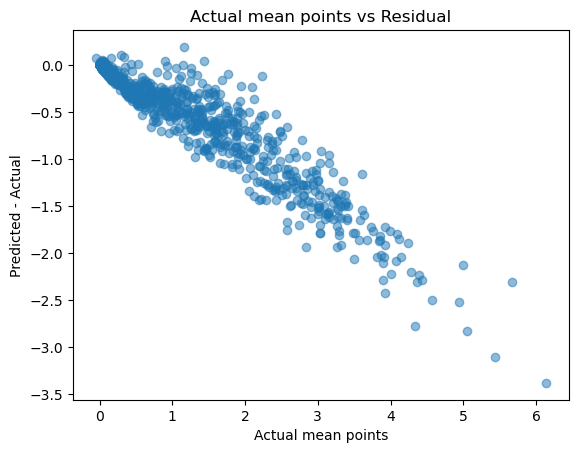

In [26]:
residual_plot(df_agg_l1)

L1 regression produces a more extreme correlation between player points average and underestimation.

In [27]:
query = """
    SELECT
        p.web_name,
        pg.player_game_key,
        pg.fixture_key,
        pg.player_id,
        pg.total_points_recalculated,
        avg(pg.total_points_recalculated) over last_5_games as yhat
    FROM dev_serving.fact_player_game pg
    JOIN dev_serving.dim_fixture f
    ON pg.fixture_key = f.fixture_key
    JOIN dev_serving.dim_player p
    ON pg.player_id = p.player_id
    WHERE f.season > 2024
    WINDOW last_5_games as (
        partition by pg.player_id
        order by kickoff_time
        rows between 5 preceding and 1 preceding
    )
"""

df_naive = query_database(query)
df_naive = df_naive.fillna(0)

In [28]:
mae = mean_absolute_error(df_naive['total_points_recalculated'], df_naive['yhat'])
mse = mean_squared_error(df_naive['total_points_recalculated'], df_naive['yhat'])
spearman = spearmanr(df_naive['total_points_recalculated'], df_naive['yhat']).correlation

print(f'Test MAE: {mae}')
print(f'Test MSE: {mse}')
print(f'Test Spearman: {spearman}')

Test MAE: 1.0677604789093513
Test MSE: 4.497500774576162
Test Spearman: 0.6853957692846453


             actual_mean  residual
actual_mean     1.000000 -0.156423
residual       -0.156423  1.000000


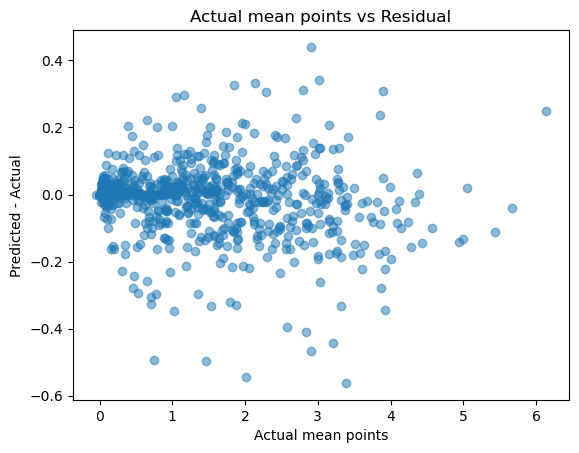

In [29]:
df_agg_naive = get_aggregates(df_naive)
residual_plot(df_agg_naive)

Underprediction of elite players does not reflect in a naive rolling 5 game average prediction

In [30]:
query = """
    SELECT
        p.web_name,
        pg.player_game_key,
        pg.fixture_key,
        pg.player_id,
        pg.total_points_recalculated,
        avg(pg.total_points_recalculated) over last_5_games as avg_points_last_5_games
    FROM dev_serving.fact_player_game pg
    JOIN dev_serving.dim_fixture f
    ON pg.fixture_key = f.fixture_key
    JOIN dev_serving.dim_player p
    ON pg.player_id = p.player_id
    WINDOW last_5_games as (
        partition by pg.player_id
        order by kickoff_time
        rows between 5 preceding and 1 preceding
    )
"""

df_aug = query_database(query)
df_aug = df_aug.fillna(0)

In [31]:
df_aug = pd.merge(df_all, df_aug[['player_game_key', 'avg_points_last_5_games']])

train_aug = df_aug[df_aug['season'] < 2025]
test_aug = df_aug[df_aug['season'] >= 2025]

In [32]:
df_training_aug, categories_aug = preprocess_data(train_aug, fit=True)
df_test_aug, _ = preprocess_data(test_aug, fit_categories=categories_aug, fit=False)

X_train_aug = df_training.drop(columns=['points'])
y_train_aug = df_training['points']

X_test_aug = df_test.drop(columns=['points'])
y_test_aug = df_test['points']

In [33]:
lgbm = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_aug, yhat_train = train_baseline_model(lgbm, X_train_aug, y_train_aug)
yhat_aug = test_baseline_model(model_aug, X_test_aug, y_test_aug)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044116 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54077
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 247
[LightGBM] [Info] Start training from score 1.325831
Training MAE: 1.04654856458235
Training MSE: 3.516575070659153
Training Spearman: 0.7097071206119133
Test MAE: 1.0270434865091145
Test MSE: 3.790800308291212
Test Spearman: 0.699758012505235


In [34]:
aug_summary = get_summary(test_aug, X_test_aug, yhat_aug)
df_agg_aug = get_aggregates(aug_summary)
df_agg_aug.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,1.492902,5.288236,5.249575,6.144737,76
223094,Haaland,1.611774,4.842520,5.641067,5.666667,81
141746,B.Fernandes,1.112908,4.944538,4.354929,5.432099,81
446008,Mbeumo,0.925637,4.392895,4.519813,5.049383,81
178186,Bowen,0.872381,3.669696,4.464170,5.000000,76
437730,Semenyo,0.694833,4.124153,4.290311,4.938272,81
222531,Gibbs-White,0.725544,4.153126,3.653960,4.567901,81
244850,Rogers,0.729923,3.754791,3.665207,4.432099,81
244851,Palmer,1.643504,5.004196,4.217940,4.395062,81


             actual_mean  residual
actual_mean     1.000000 -0.551477
residual       -0.551477  1.000000


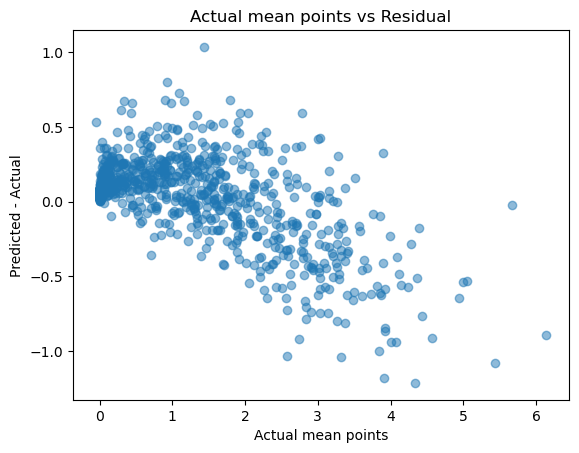

In [35]:
residual_plot(df_agg_aug)

Adding rolling average as a feature does not affect systemic underestimation of elite players

In [36]:
def add_gameweek(df):
    query = """
    select
    	f.canon_gameweek as gameweek,
        f.season,
    	pg.player_game_key
    from dev_serving.fact_player_game pg
    join dev_serving.dim_fixture f
    	on pg.fixture_key = f.fixture_key
    """

    df_gw = query_database(query)

    df_merge = pd.merge(df, df_gw, on='player_game_key', how='inner')

    return df_merge

In [37]:
def spearmanr_by_gw(df):
    """Compute spearman rank correlation between predicted and actual values, split by gameweek."""

    df_group = df[['player_game_key', 'total_points_recalculated', 'yhat', 'gameweek', 'season']]
    
    df_corr = df_group.groupby(['season', 'gameweek']).corr(method='spearman', numeric_only='true')

    r_by_gw = df_corr.xs('yhat', level=2)['total_points_recalculated']

    return r_by_gw.reset_index().rename(columns={'total_points_recalculated': 'spearman'})

In [38]:
df_gw_summary = add_gameweek(df_testing_summary)
df_gw_spearman = spearmanr_by_gw(df_gw_summary)

In [39]:
df_gw_naive = add_gameweek(df_naive)
df_naive_gw_spearman = spearmanr_by_gw(df_gw_naive)
df_spearman_by_gw = pd.merge(df_gw_spearman, df_naive_gw_spearman, on=['season', 'gameweek'])
df_spearman_by_gw.rename(columns={'spearman_x': 'test_spearman', 'spearman_y': 'naive_spearman'}).mean()

season            2025.592593
gameweek            18.481481
test_spearman        0.697197
naive_spearman       0.693285
dtype: float64

In [40]:
def get_predictions(model):
    query = """
        SELECT *
        FROM dev_ml.prediction_features
    """
    
    df_pred = query_database(query)
    df_pred_features, _ = preprocess_data(df_pred, fit_categories=categories)

    predictions = model_l2.predict(df_pred_features)

    df = df_pred.copy()
    df.loc[df_pred.index, 'xP'] = predictions

    query = """
        SELECT fixture_key, canon_gameweek
        FROM dev_serving.dim_fixture
    """
    
    df_fixture = query_database(query)
    
    query = """
        SELECT player_id, web_name
        FROM dev_serving.dim_player
    """
    
    df_player = query_database(query)

    df_pf = pd.merge(df, df_fixture, on='fixture_key')
    df_pfp = pd.merge(df_pf, df_player, on='player_id')
    df_pred_info = df_pfp[['fixture_key', 'player_id', 'fpl_position', 'web_name', 'canon_gameweek', 'xP']]

    return df_pred_info

In [41]:
df_predictions = get_predictions(model_l2)

In [42]:
query = 'canon_gameweek < 6'
df_predictions.query(query).groupby(['player_id', 'fpl_position', 'web_name'])['xP'].sum().sort_values(ascending=False).head(15)

Series([], Name: xP, dtype: float64)

In [47]:
def save_model(model, model_name, training_set):
    # Save Model
    version = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S")
    model_dir = Path(f'../models/{model_name}/{version}')
    model_dir.mkdir(parents=True, exist_ok=True)    
    
    with open(model_dir / 'model.pkl', 'wb') as file:
        pickle.dump(model, file)

    categorical_columns = training_set.select_dtypes(include='category').columns.tolist()
    category_maps = {
        col: training_set[col].cat.categories.tolist()
        for col in categorical_columns
    }

    # Write metadata
    meta = {
        'model_name': model_name,
        'model_version': version,
        'target': 'total_points_recalculated',
        'feature_columns': list(X_train.columns),
        'categorical_columns': list(categorical_columns),
        'category_maps': category_maps,
        'trained_through_season': int(train['season'].max()),
        'trained_at': datetime.now(timezone.utc).isoformat(),
        'framework': 'lightgbm',
        'framework_version': lgb.__version__,
        'training_params': {
            'objective': 'regression',
            'n_estimators': 500,
            'learning_rate': 0.05,
            'num_leaves': 31,
            'random_state': 42,
            'n_jobs': -1
        }
    }

    with open(model_dir / 'meta.json', 'w') as file:
        json.dump(meta, file, indent=2)

In [48]:
save_model(model_l2, 'baseline_model', X_train)